In [ ]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Accidents Dataset") \
    .getOrCreate()

df = spark.read.option("header", True).csv(
    "hdfs://namenode:9000/user/gyembo/project/traffic_cleaned_eda_csv"
)
df.show(5)
df.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/24 07:07:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/24 07:07:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--------------+--------------+----+-----+---------+----+------------------+
|Severity|          Start_Time|            End_Time|         Start_Lat| Start_Lng|Distance(mi)|      City|   County|State|Country|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Weather_Condition|Amenity|Crossing|Junction|Railway|Station| Stop|Traffic_Signal|Sunrise_Sunset|Hour|Month|DayOfWeek|Year|  Duration_Minutes|
+--------+--------------------+--------------------+------------------+----------+------------+----------+---------+-----+-------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+--------+--------+-------+-------+-----+--

In [ ]:
from pyspark.sql.functions import col, hour, dayofweek, month
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.style.use("dark_background")
sns.set_palette("viridis")

In [ ]:
# Numerical summary
df.select(
    "Severity",
    "Temperature(F)",
    "Visibility(mi)"
).describe().show()

+-------+------------------+------------------+------------------+
|summary|          Severity|    Temperature(F)|    Visibility(mi)|
+-------+------------------+------------------+------------------+
|  count|           7728394|           7728394|           7728394|
|   mean| 2.212384487643875|61.712827490420366| 9.111220689576692|
| stddev|0.4875313339360388|18.814026710362295|2.6608192337857868|
|    min|                 1|              -0.0|               0.0|
|    max|                 4|              99.9|              98.0|
+-------+------------------+------------------+------------------+



### UNIVARIATE ANALYSIS (SINGLE VARIABLE)

#### Severity Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#   Color Palatte


PALETTE = {
    "bg":        "#0d1117",
    "panel":     "#161b22",
    "accent1":   "#58a6ff",
    "accent2":   "#3fb950",
    "accent3":   "#f78166",
    "accent4":   "#d29922",
    "accent5":   "#bc8cff",
    "text":      "#e6edf3",
    "grid":      "#21262d",
}

# severity color

SEV_COLORS = {
    1: PALETTE["accent2"],
    2: PALETTE["accent1"],
    3: PALETTE["accent4"],
    4: PALETTE["accent3"]
}

# Category color

CAT_CMAP = [
    PALETTE["accent1"], PALETTE["accent5"], PALETTE["accent2"],
    PALETTE["accent4"], PALETTE["accent3"],
    "#79c0ff", "#56d364", "#ffa657", "#ff7b72", "#cae8ff"
]

# Global style

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["grid"],
    "axes.labelcolor":   PALETTE["text"],
    "xtick.color":       PALETTE["text"],
    "ytick.color":       PALETTE["text"],
    "text.color":        PALETTE["text"],
    "grid.color":        PALETTE["grid"],
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
})



def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(True, axis="y", alpha=0.4)

    # SAFE spine removal (avoids version errors)
    for spine in ax.spines.values():
        spine.set_visible(False)

    return ax

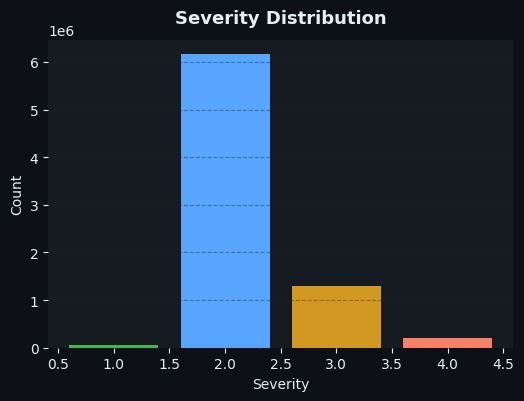

In [ ]:

# Spark aggregation
sev = df.groupBy("Severity") \
    .count() \
    .orderBy(col("Severity"))

# Convert only aggregated result
sev_pd = sev.toPandas()

sev_pd["Severity"] = sev_pd["Severity"].astype(int)

# Use your palette
colors = [SEV_COLORS[s] for s in sev_pd["Severity"]]

# Plot
fig, ax = plt.subplots(figsize=(6,4))

ax.bar(
    sev_pd["Severity"],
    sev_pd["count"],
    color=colors
)

style_ax(ax, "Severity Distribution", "Severity", "Count")

plt.show()

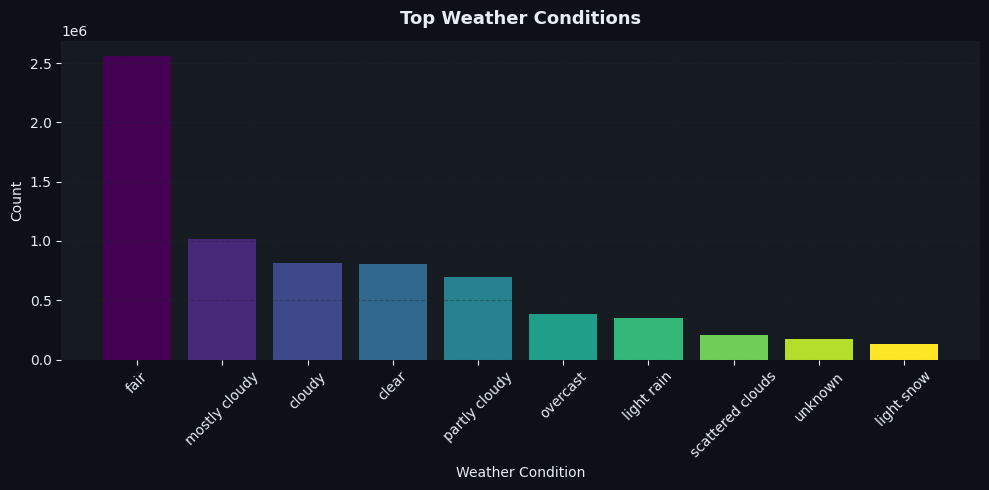

In [ ]:
# Spark aggregation
weather = df.groupBy("Weather_Condition") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

weather_pd = weather.toPandas()

# Create colors using palette system
colors = np.linspace(0, 1, len(weather_pd))
colors = plt.cm.viridis(colors)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    weather_pd["Weather_Condition"],
    weather_pd["count"],
    color=colors
)

style_ax(ax, "Top Weather Conditions", "Weather Condition", "Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

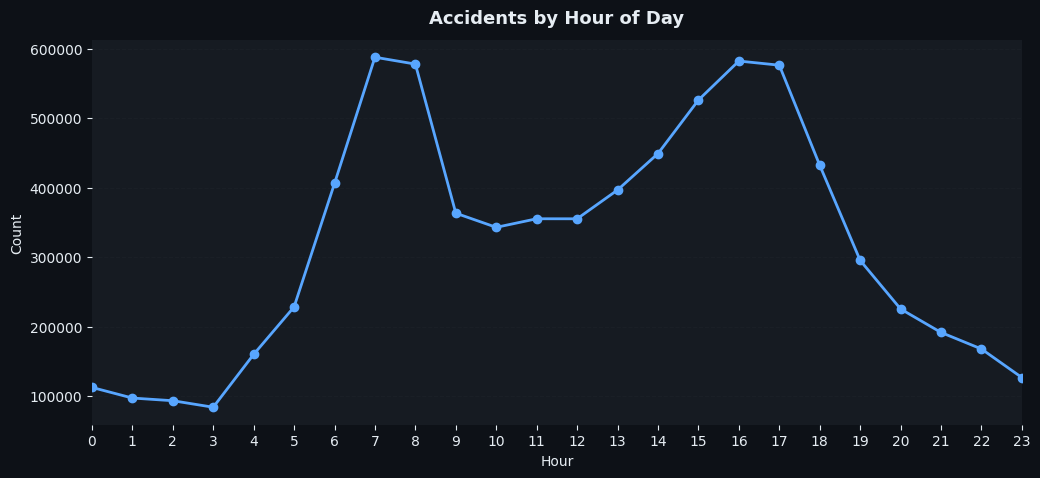

In [ ]:

# Spark aggregation
hour_df = df.groupBy("Hour") \
    .count() \
    .orderBy(col("Hour"))

#Convert only aggregated result
hour_pd = hour_df.toPandas()

hour_pd["Hour"] = hour_pd["Hour"].astype(int)

# Sort
hour_pd = hour_pd.sort_values("Hour")

# Plot
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    hour_pd["Hour"],
    hour_pd["count"],
    color=PALETTE["accent1"],   # using your system palette
    marker="o",
    linewidth=2
)

style_ax(ax, "Accidents by Hour of Day", "Hour", "Count")

ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)

plt.show()

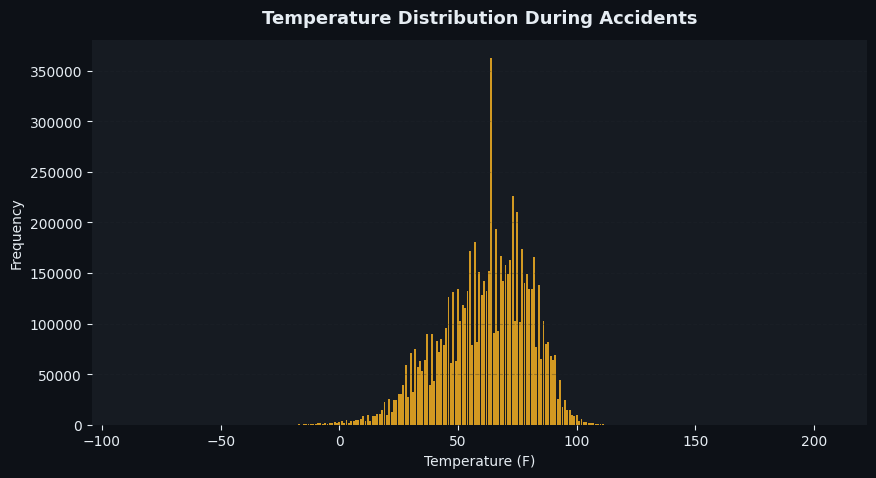

In [ ]:
from pyspark.sql.functions import floor

binned_df = df.select("Temperature(F)") \
    .dropna() \
    .withColumn("temp_bin", floor(col("Temperature(F)")))

# Aggregate in Spark
hist_df = binned_df.groupBy("temp_bin") \
    .count() \
    .orderBy("temp_bin")

# Convert only aggregated result
hist_pd = hist_df.toPandas()


hist_pd["temp_bin"] = hist_pd["temp_bin"].astype(int)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    hist_pd["temp_bin"],
    hist_pd["count"],
    color=PALETTE["accent4"]  # using palette
)

style_ax(
    ax,
    "Temperature Distribution During Accidents",
    "Temperature (F)",
    "Frequency"
)

ax.grid(True, axis="y", alpha=0.3)

plt.show()

### Bivariate Analysis


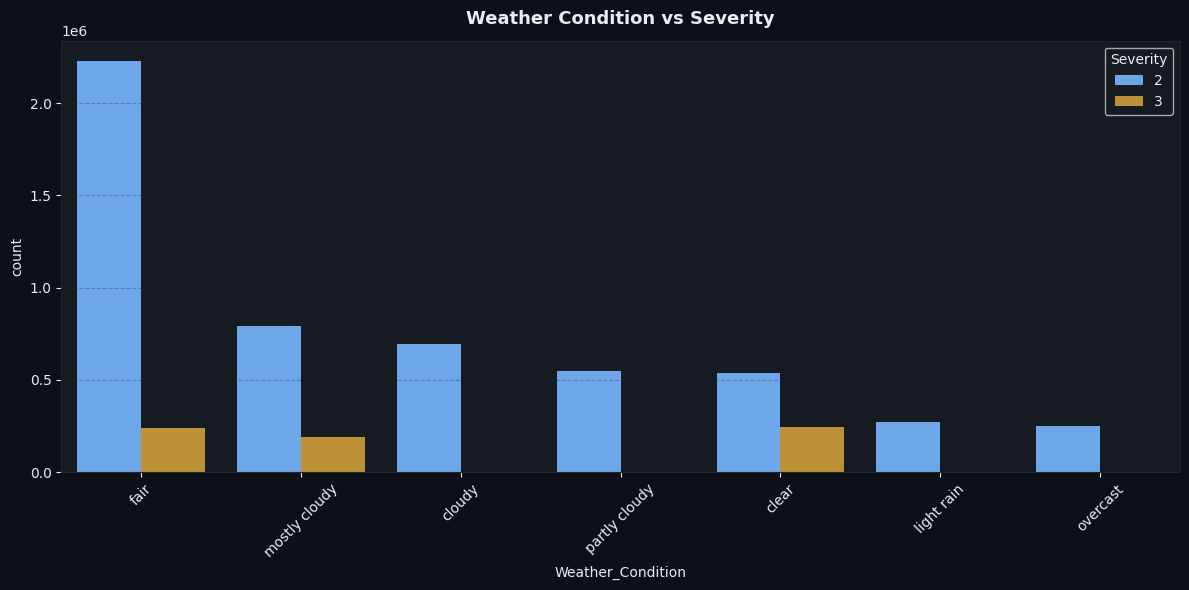

In [ ]:
# Spark aggregation
ws = df.groupBy("Weather_Condition", "Severity") \
    .count()

# Reduce data inside Spark 
ws_top = ws.orderBy(col("count").desc()).limit(10)

# Convert only small dataset
ws_pd = ws_top.toPandas()

ws_pd["Severity"] = ws_pd["Severity"].astype(int)

# Plot using  palette
plt.figure(figsize=(12,6))

sns.barplot(
    data=ws_pd,
    x="Weather_Condition",
    y="count",
    hue="Severity",
    palette=SEV_COLORS   # using palette 
)

plt.title("Weather Condition vs Severity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", alpha=0.3)

plt.show()

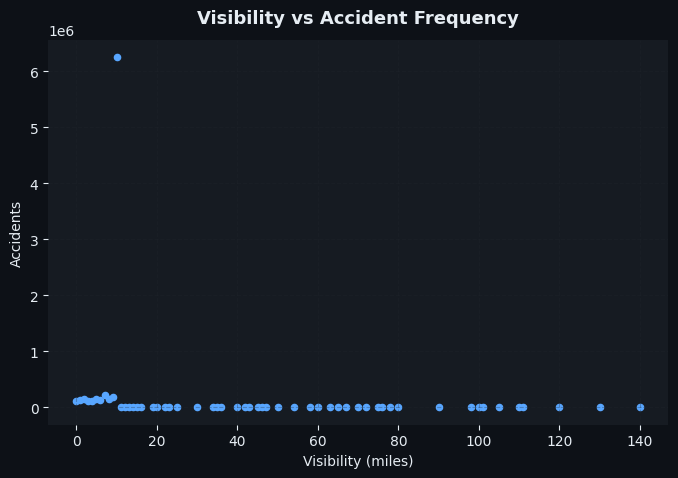

In [ ]:
vis = df.select("Visibility(mi)") \
    .dropna() \
    .withColumn("vis_bin", (floor(col("Visibility(mi)") / 1) * 1)) \
    .groupBy("vis_bin") \
    .count() \
    .orderBy("vis_bin")

# Safe Limit
vis_small = vis.limit(300)  

# Convert only small data
vis_pd = vis_small.toPandas()

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    vis_pd["vis_bin"],
    vis_pd["count"],
    color=PALETTE["accent1"],
    s=20
)

style_ax(
    plt.gca(),
    "Visibility vs Accident Frequency",
    "Visibility (miles)",
    "Accidents"
)

plt.grid(True, alpha=0.3)
plt.show()

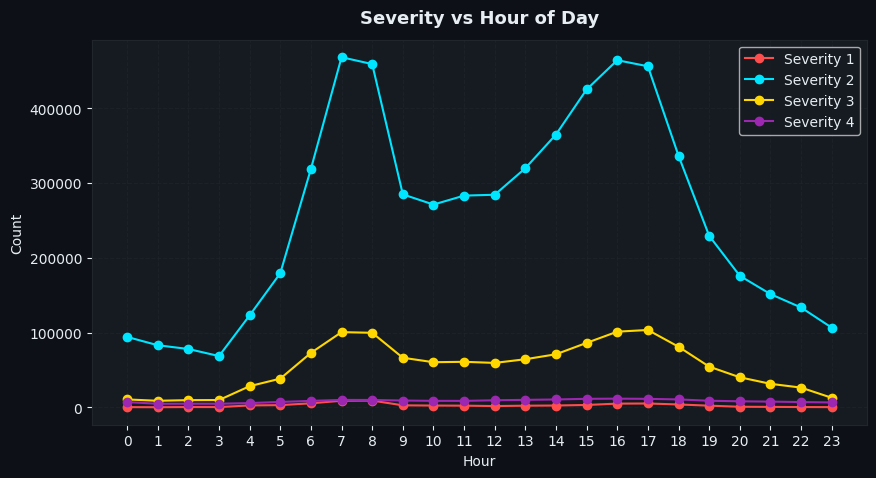

In [ ]:

# Aggregate in Spark
hs = df.groupBy("Hour", "Severity") \
    .count() \
    .orderBy("Hour")

# SAFE transfer
hs_pd = hs.toPandas()

# Ensure correct types
hs_pd["Hour"] = hs_pd["Hour"].astype(int)
hs_pd["Severity"] = hs_pd["Severity"].astype(int)

plt.figure(figsize=(10,5))

colors = ["#ff4d4d", "#00e5ff", "#FFD700", "#9c27b0"]

for i, s in enumerate(sorted(hs_pd["Severity"].unique())):
    temp = hs_pd[hs_pd["Severity"] == s].sort_values("Hour")
    
    plt.plot(
        temp["Hour"],
        temp["count"],
        marker="o",
        color=colors[i],
        label=f"Severity {s}"
    )

plt.title("Severity vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.show()

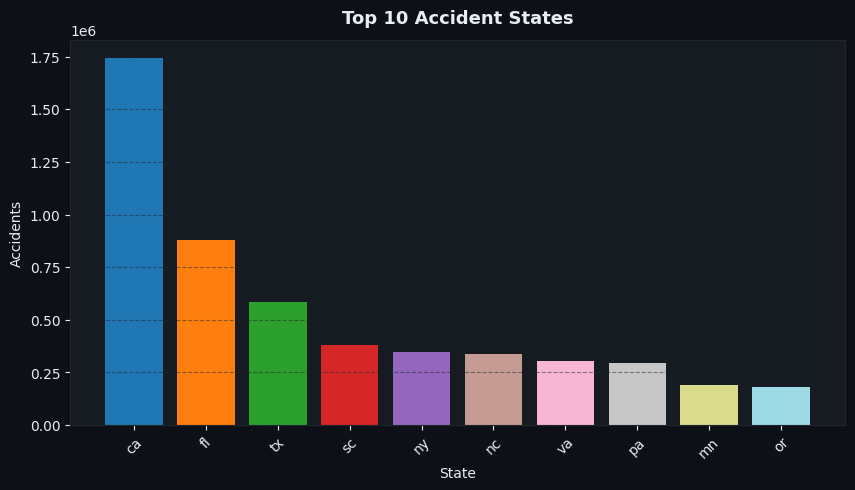

In [ ]:

# Spark aggregation
state = df.groupBy("State") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(10)

# Convert ONLY small result
state_pd = state.toPandas()

# Colors
colors = plt.cm.tab20(np.linspace(0, 1, len(state_pd)))

# Step 4: Plot
plt.figure(figsize=(10,5))

plt.bar(
    state_pd["State"],
    state_pd["count"],
    color=colors
)

plt.title("Top 10 Accident States")
plt.xlabel("State")
plt.ylabel("Accidents")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()